# DLMI Project — Cervix VIA Image Classification (Normal vs Precancerous vs Cancerous)


Includes:
- Dataset sanity checks (paths, splits, class distribution)
- A **simple baseline** (SmallCNN trained from scratch)
- A **transfer-learning model** (EfficientNet-B0)
- **Strong augmentations** + class-imbalance mitigation
- Quantitative evaluation on **train/val/test**, including **95% bootstrap confidence intervals**

In [ ]:
# =========================
# Colab Setup 
# =========================
import os, json, math, random, time
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from PIL import Image

# Optional: sklearn is usually available on Colab; install if missing.
try:
    from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
except Exception:
    !pip -q install scikit-learn
    from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

import matplotlib.pyplot as plt

# Mount Google Drive (recommended for reproducibility)
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print("Not running on Colab; skipping drive.mount().")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [101]:
# =========================
# Configuration
# =========================

# NOTE:
# Your previous notebook used /content/drive/MyDrive/MLProject/...
# So we keep the same convention here for minimal edits.

PROJECT_DIR = Path("/content/drive/MyDrive/cervical_project")
CSV_PATH = PROJECT_DIR / "labels_merged_cases_plus_flashcards.csv"  # <-- change if needed

# Default CSV name (the merged cases + flashcards file)
CSV_CANDIDATES = [
    PROJECT_DIR / "labels_merged_cases_plus_flashcards.csv",
    PROJECT_DIR / "labels_merged_cases_plus_flashcards (1).csv",
    PROJECT_DIR / "labels_combine.csv",  # older name in some notebooks
    PROJECT_DIR / "labels.csv",
]

def find_existing_path(candidates):
    for p in candidates:
        if p.exists():
            return p
    return None

CSV_PATH = find_existing_path(CSV_CANDIDATES)

# Auto-detect the image root directory:
# We look for a folder that contains "j1data" and at least one "Case xxx" folder.
def autodetect_data_root(project_dir: Path) -> Path:
    # 1) try project_dir itself
    if (project_dir / "j1data").exists() and any(project_dir.glob("Case *")):
        return project_dir
    # 2) search 2 levels deep
    for p in project_dir.glob("*"):
        if p.is_dir() and (p / "j1data").exists() and any(p.glob("Case *")):
            return p
    for p in project_dir.glob("*/*"):
        if p.is_dir() and (p / "j1data").exists() and any(p.glob("Case *")):
            return p
    return project_dir  # fallback

from pathlib import Path
import pandas as pd

df = pd.read_csv(CSV_PATH)

ROOTS = [
    Path("/content/drive/MyDrive/cervical_project/data/images"),
    Path("/content/drive/MyDrive/cervical_project/cdata/image"),
    Path("/content/drive/MyDrive/cervical_project/j1data"),
    Path("/content/drive/MyDrive/cervical_project"),
]

def resolve(rel):
    rel = str(rel).lstrip("/")
    for r in ROOTS:
        p = r / rel
        if p.exists():
            return str(p)
    return None

path_col = "Path" if "Path" in df.columns else "image_path"
df["abs_path"] = df[path_col].apply(resolve)

missing = df["abs_path"].isna().sum()
print("Missing files:", missing)

# Save the missing items list.
df[df["abs_path"].isna()][[path_col]].to_csv("missing_after_resolve.csv", index=False)

# Filter out rows with missing values.
df = df[df["abs_path"].notna()].reset_index(drop=True)


DATA_ROOT = autodetect_data_root(PROJECT_DIR)

# Output directory
RUNS_DIR = PROJECT_DIR / "runs_final_project"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

# Training hyperparameters
NUM_CLASSES = 3
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 40
LR = 5e-5
WEIGHT_DECAY = 3e-5
PATIENCE = 10  # early stopping patience (epochs)
NUM_WORKERS = 2

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_ROOT  :", DATA_ROOT)
print("CSV_PATH   :", CSV_PATH)
print("Device     :", device)


Missing files: 12
PROJECT_DIR: /content/drive/MyDrive/cervical_project
DATA_ROOT  : /content/drive/MyDrive/cervical_project/cdata/image
CSV_PATH   : /content/drive/MyDrive/cervical_project/labels_merged_cases_plus_flashcards.csv
Device     : cuda


In [ ]:
# =========================
# Load CSV + Sanity Checks 
# =========================

assert CSV_PATH is not None and Path(CSV_PATH).exists(), (
    "Could not find the CSV. Put it in PROJECT_DIR and/or update CSV_CANDIDATES."
)

df = pd.read_csv(CSV_PATH)

# Expected columns for this merged CSV (from our pipeline)
expected_cols = {"image_path", "class", "split"}
missing_cols = expected_cols - set(df.columns)
assert not missing_cols, f"CSV missing columns: {missing_cols}. Found: {df.columns.tolist()}"

# Build absolute paths using multi-root resolver (NOT by joining DATA_ROOT)
# This uses ROOTS + resolve(rel) that you already defined above.
df["abs_path"] = df["image_path"].apply(resolve)

# Drop missing files so DataLoader never crashes
missing_mask = df["abs_path"].isna()
print("Total rows:", len(df))
print("Missing files:", int(missing_mask.sum()))
if missing_mask.any():
    print("Example missing:", df.loc[missing_mask, "image_path"].head(10).tolist())
    df.loc[missing_mask, ["image_path"]].to_csv("missing_after_resolve.csv", index=False)

df = df.loc[~missing_mask].reset_index(drop=True)

# Basic dataset statistics
print("\nSplit counts:")
print(df["split"].value_counts(dropna=False))

print("\nClass counts (overall):")
print(df["class"].value_counts().sort_index())

if "class_name" in df.columns:
    print("\nClass name counts:")
    print(df["class_name"].value_counts())

# Ensure splits exist
assert set(df["split"].unique()).issuperset({"train", "val", "test"}), (
    f"Expected train/val/test splits. Found: {sorted(df['split'].unique())}"
)

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

print("\nTrain/Val/Test:", len(train_df), len(val_df), len(test_df))


Total rows: 535
Missing files: 12
Example missing: ['Case 010/AJG0.jpg', 'Case 010/AJG1.jpg', 'Case 015/AIH0.jpg', 'Case 015/AIH1.jpg', 'Case 035/AGX0.jpg', 'Case 035/AGX1.jpg', 'Case 118/ABY0.jpg', 'Case 118/ABY1.jpg', 'Case 118/ABY2.jpg', 'Case 166/APW1.jpg']

Split counts:
split
train    361
val       81
test      81
Name: count, dtype: int64

Class counts (overall):
class
0    261
1    210
2     52
Name: count, dtype: int64

Class name counts:
class_name
Normal          261
Precancerous    210
Cancerous        52
Name: count, dtype: int64

Train/Val/Test: 361 81 81


In [ ]:
# =========================
# Transforms (Strong Augmentations)
# =========================
# The dataset is relatively small, so we rely on strong augmentations to reduce overfitting and improve generalization.

train_tfms = transforms.Compose([
    # Key change: reduce the chance of cropping away lesion regions
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.90, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),

    # Lighting/contrast variability is common in VIA images
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.03),
    transforms.RandomAutocontrast(p=0.3),
    transforms.RandomEqualize(p=0.2),

    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])


In [ ]:
# =========================
# Dataset 
# =========================
class CervixDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = Path(row["abs_path"])
        label = int(row["class"])

        # Load image
        img = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        return img, label

train_ds = CervixDataset(train_df, transform=train_tfms)
val_ds   = CervixDataset(val_df,   transform=eval_tfms)
test_ds  = CervixDataset(test_df,  transform=eval_tfms)

# WeightedRandomSampler to mitigate class imbalance 
class_counts = train_df["class"].value_counts().sort_index()
weights_per_class = 1.0 / class_counts
sample_weights = train_df["class"].map(weights_per_class).values

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print("Train batches:", len(train_loader), "Val batches:", len(val_loader), "Test batches:", len(test_loader))


Train batches: 12 Val batches: 3 Test batches: 3


In [ ]:
# =========================
# Models
# =========================

class SmallCNN(nn.Module):
    """A minimal CNN baseline trained from scratch (benchmark reference)."""
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)

def build_efficientnet_b0(num_classes=3, unfreeze_last_n_blocks=3):
    """EfficientNet-B0 with transfer learning.

    Freezes the backbone and unfreezes the last N feature blocks + classifier.
    """
    weights = EfficientNet_B0_Weights.DEFAULT
    model = efficientnet_b0(weights=weights)

    # Replace classifier for 3-way classification
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)

    # Freeze everything
    for p in model.parameters():
        p.requires_grad = False

    # Unfreeze classifier
    for p in model.classifier.parameters():
        p.requires_grad = True

    # Unfreeze last N blocks of model.features 
    n = len(model.features)
    start = max(0, n - unfreeze_last_n_blocks)
    for i in range(start, n):
        for p in model.features[i].parameters():
            p.requires_grad = True

    return model



In [ ]:
# =========================
# Training and Evaluation Utilities
# =========================
def set_trainable_param_count(model: nn.Module):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable, trainable / total

@torch.no_grad()
def run_eval(model, loader, criterion_w, criterion_plain):
    model.eval()
    losses_w = []
    losses_plain = []
    all_preds = []
    all_targets = []

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)

        loss_w = criterion_w(logits, y)
        loss_p = criterion_plain(logits, y)

        losses_w.append(loss_w.item())
        losses_plain.append(loss_p.item())

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy().tolist())
        all_targets.extend(y.cpu().numpy().tolist())

    acc = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average="macro")

    return (
        float(np.mean(losses_w)),
        float(np.mean(losses_plain)),
        acc,
        macro_f1,
        np.array(all_preds),
        np.array(all_targets),
    )


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))

def plot_history(history, title="Training Curves"):
    plt.figure()
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.legend()
    plt.title(title)
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.show()

    plt.figure()
    plt.plot(history["val_acc"], label="val_acc")
    plt.plot(history["val_macro_f1"], label="val_macro_f1")
    plt.legend()
    plt.title(title)
    plt.xlabel("epoch")
    plt.ylabel("metric")
    plt.show()

def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=1000, alpha=0.05, seed=42):
    """Nonparametric bootstrap CI for a metric computed on (y_true, y_pred)."""
    rng = np.random.default_rng(seed)
    n = len(y_true)
    stats = []
    idx = np.arange(n)
    for _ in range(n_boot):
        sample = rng.choice(idx, size=n, replace=True)
        stats.append(metric_fn(y_true[sample], y_pred[sample]))
    stats = np.array(stats)
    lo = np.quantile(stats, alpha/2)
    hi = np.quantile(stats, 1 - alpha/2)
    return float(np.mean(stats)), float(lo), float(hi)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.0, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        self.reduction = reduction
        if alpha is not None:
            self.register_buffer("alpha", torch.tensor(alpha, dtype=torch.float32))
        else:
            self.alpha = None

    def forward(self, logits, targets):
        num_classes = logits.size(1)

        # label smoothing
        if self.label_smoothing > 0:
            with torch.no_grad():
                true_dist = torch.zeros_like(logits)
                true_dist.fill_(self.label_smoothing / (num_classes - 1))
                true_dist.scatter_(1, targets.unsqueeze(1), 1 - self.label_smoothing)
            log_probs = torch.log_softmax(logits, dim=1)
            ce = -(true_dist * log_probs).sum(dim=1)
        else:
            ce = nn.functional.cross_entropy(logits, targets, reduction="none")

        pt = torch.exp(-ce)  # pt = softmax prob of the true class (approx)
        focal = (1 - pt) ** self.gamma * ce

        if self.alpha is not None:
            a = self.alpha.to(logits.device)[targets]
            focal = a * focal

        if self.reduction == "mean":
            return focal.mean()
        elif self.reduction == "sum":
            return focal.sum()
        else:
            return focal



Baseline params: total=94,083 trainable=94,083 (100.00%)
[Baseline] epoch=01 train_loss=1.1577 val_loss_plain=1.1080 val_loss_w=1.1235 val_acc=0.1358 val_f1=0.0797
[Baseline] epoch=02 train_loss=1.1410 val_loss_plain=1.1098 val_loss_w=1.1021 val_acc=0.1852 val_f1=0.1455
[Baseline] epoch=03 train_loss=1.1229 val_loss_plain=1.1088 val_loss_w=1.0892 val_acc=0.2346 val_f1=0.1924
[Baseline] epoch=04 train_loss=1.1306 val_loss_plain=1.1268 val_loss_w=1.0910 val_acc=0.2469 val_f1=0.2034
[Baseline] epoch=05 train_loss=1.0980 val_loss_plain=1.1124 val_loss_w=1.0858 val_acc=0.2963 val_f1=0.2569
[Baseline] epoch=06 train_loss=1.0905 val_loss_plain=1.1160 val_loss_w=1.0869 val_acc=0.2346 val_f1=0.2105
[Baseline] epoch=07 train_loss=1.0913 val_loss_plain=1.1030 val_loss_w=1.0856 val_acc=0.2469 val_f1=0.2297
[Baseline] epoch=08 train_loss=1.0983 val_loss_plain=1.1061 val_loss_w=1.0868 val_acc=0.2469 val_f1=0.2297
[Baseline] epoch=09 train_loss=1.0941 val_loss_plain=1.0895 val_loss_w=1.0860 val_acc=0

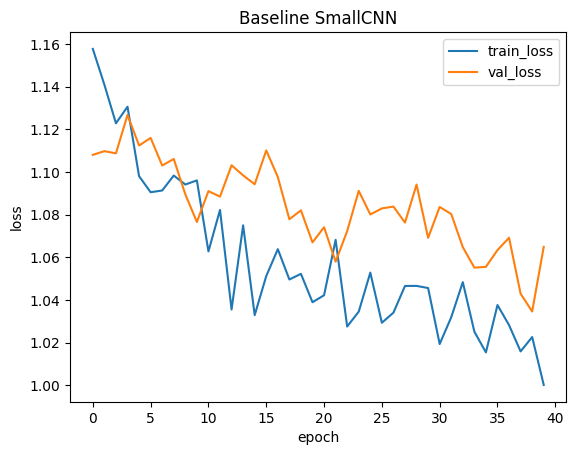

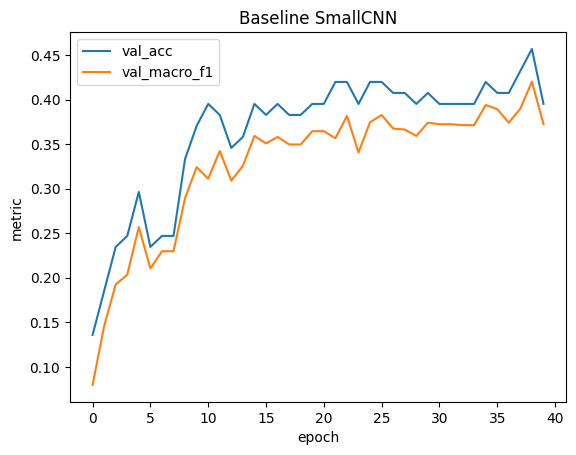

In [ ]:
# =========================
# 1) Baseline: SmallCNN 
# =========================
baseline = SmallCNN(num_classes=NUM_CLASSES).to(device)
total, trainable, ratio = set_trainable_param_count(baseline)
print(f"Baseline params: total={total:,} trainable={trainable:,} ({ratio*100:.2f}%)")

baseline_run_dir = RUNS_DIR / "baseline_smallcnn"
baseline_run_dir.mkdir(parents=True, exist_ok=True)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
plain_criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(baseline.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

best_val_f1 = -1.0
best_path = baseline_run_dir / "best.pt"
history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_macro_f1": []}
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(baseline, train_loader, optimizer, criterion)

    val_loss_w, val_loss_plain, val_acc, val_f1, _, _ = run_eval(
        baseline, val_loader, criterion, plain_criterion
    )

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss_plain)
    history["val_acc"].append(val_acc)
    history["val_macro_f1"].append(val_f1)

    print(f"[Baseline] epoch={epoch:02d} "
          f"train_loss={tr_loss:.4f} "
          f"val_loss_plain={val_loss_plain:.4f} "
          f"val_loss_w={val_loss_w:.4f} "
          f"val_acc={val_acc:.4f} val_f1={val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save({"model": baseline.state_dict(),
                    "epoch": epoch,
                    "best_val_f1": best_val_f1}, best_path)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

# Save history
with open(baseline_run_dir / "history.json", "w") as f:
    json.dump(history, f, indent=2)

plot_history(history, title="Baseline SmallCNN")


In [108]:
# =========================
# Baseline Test Evaluation
# =========================
ckpt = torch.load(best_path, map_location=device)
baseline.load_state_dict(ckpt["model"])

test_loss_w, test_loss_plain, test_acc, test_f1, test_preds, test_targets = run_eval(
    baseline, test_loader, criterion, plain_criterion
)

print(f"[Baseline] test_acc={test_acc:.4f} test_macro_f1={test_f1:.4f} "
      f"test_loss_plain={test_loss_plain:.4f} test_loss_w={test_loss_w:.4f}")
print(classification_report(test_targets, test_preds, digits=4))
print(confusion_matrix(test_targets, test_preds))

# 95% bootstrap CI
acc_mean, acc_lo, acc_hi = bootstrap_ci(test_targets, test_preds, lambda yt, yp: accuracy_score(yt, yp))
f1_mean, f1_lo, f1_hi   = bootstrap_ci(test_targets, test_preds, lambda yt, yp: f1_score(yt, yp, average="macro"))

baseline_summary = {
    "model": "SmallCNN",
    "best_val_macro_f1": ckpt["best_val_f1"],
    "test_acc": test_acc,
    "test_macro_f1": test_f1,
    "test_acc_ci95": [acc_lo, acc_hi],
    "test_macro_f1_ci95": [f1_lo, f1_hi],
}
with open(baseline_run_dir / "summary.json", "w") as f:
    json.dump(baseline_summary, f, indent=2)

print("\n[Baseline] 95% CI:")
print("Accuracy:", acc_mean, (acc_lo, acc_hi))
print("Macro-F1:", f1_mean, (f1_lo, f1_hi))


[Baseline] test_acc=0.3951 test_macro_f1=0.3323 test_loss_plain=1.0256 test_loss_w=1.0660
              precision    recall  f1-score   support

           0     0.5789    0.5500    0.5641        40
           1     0.4706    0.2286    0.3077        35
           2     0.0769    0.3333    0.1250         6

    accuracy                         0.3951        81
   macro avg     0.3755    0.3706    0.3323        81
weighted avg     0.4949    0.3951    0.4208        81

[[22  7 11]
 [14  8 13]
 [ 2  2  2]]

[Baseline] 95% CI:
Accuracy: 0.3953827160493827 (0.2839506172839506, 0.49382716049382713)
Macro-F1: 0.32874985943008583 (0.23936242702650973, 0.42294463589912756)


In [113]:
baseline_summary = {
    "model": "SmallCNN",
    "best_val_macro_f1": best_val_f1,
    "test_acc": test_acc,
    "test_macro_f1": test_f1,
}
with open(baseline_run_dir / "summary.json", "w") as f:
    json.dump(baseline_summary, f, indent=2)
print("Saved:", baseline_run_dir / "summary.json")


Saved: /content/drive/MyDrive/cervical_project/runs_final_project/baseline_smallcnn/summary.json


EffNet-B0 params: total=4,011,391 trainable=3,159,583 (78.77%)
Class weights: [0.67225325 0.8130631  3.5392158 ]
[EffNet] epoch=01 train_loss=0.4972 val_loss_plain=1.0651 val_loss_w=0.5689 val_acc=0.3457 val_f1=0.3501
[EffNet] epoch=02 train_loss=0.4613 val_loss_plain=1.0548 val_loss_w=0.5511 val_acc=0.3210 val_f1=0.3256
[EffNet] epoch=03 train_loss=0.4343 val_loss_plain=1.0358 val_loss_w=0.5363 val_acc=0.3951 val_f1=0.3992
[EffNet] epoch=04 train_loss=0.3884 val_loss_plain=1.0105 val_loss_w=0.5087 val_acc=0.4198 val_f1=0.4180
[EffNet] epoch=05 train_loss=0.3660 val_loss_plain=0.9917 val_loss_w=0.4919 val_acc=0.4938 val_f1=0.4876
[EffNet] epoch=06 train_loss=0.3544 val_loss_plain=0.9814 val_loss_w=0.4851 val_acc=0.4815 val_f1=0.4778
[EffNet] epoch=07 train_loss=0.3419 val_loss_plain=0.9713 val_loss_w=0.4778 val_acc=0.5062 val_f1=0.5024
[EffNet] epoch=08 train_loss=0.3004 val_loss_plain=0.9497 val_loss_w=0.4672 val_acc=0.5185 val_f1=0.5166
[EffNet] epoch=09 train_loss=0.3020 val_loss_pl

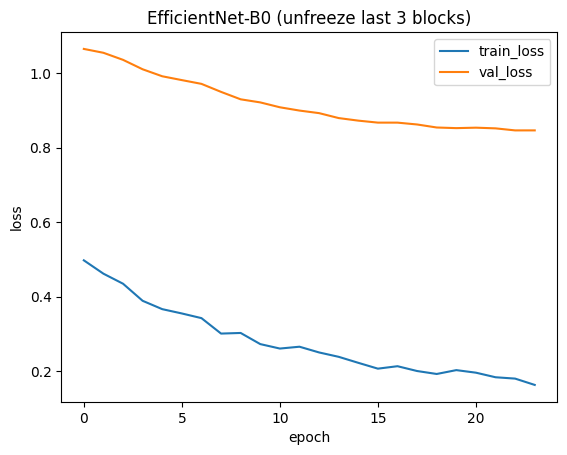

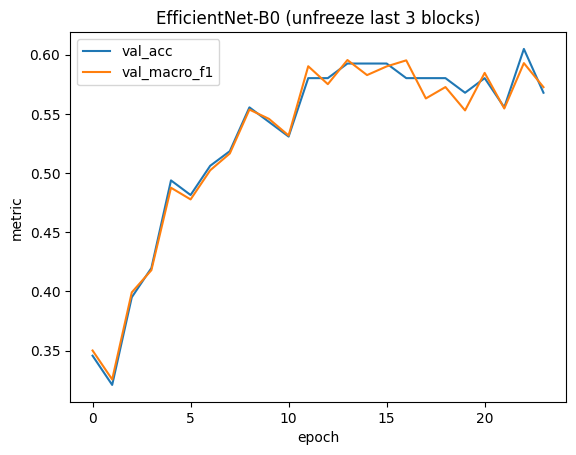

In [ ]:
# =========================
# 2) Main Model: EfficientNet-B0 
# =========================
UNFREEZE_LAST_N = 3  # matches earlier preference: unfreeze last 3 blocks + head

model = build_efficientnet_b0(num_classes=NUM_CLASSES, unfreeze_last_n_blocks=UNFREEZE_LAST_N).to(device)

total, trainable, ratio = set_trainable_param_count(model)
print(f"EffNet-B0 params: total={total:,} trainable={trainable:,} ({ratio*100:.2f}%)")

main_run_dir = RUNS_DIR / f"efficientnet_b0_unfreeze{UNFREEZE_LAST_N}"
main_run_dir.mkdir(parents=True, exist_ok=True)

# Class-weighted CE to improve minority / harder class recall (esp. Precancerous)
counts = train_df["class"].value_counts().sort_index().values
weights = counts.sum() / (len(counts) * counts)   # inverse frequency, normalized
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

criterion = FocalLoss(alpha=class_weights.detach().cpu().numpy(), gamma=2.0, label_smoothing=0.05)
plain_criterion = nn.CrossEntropyLoss()  # monitoring/plotting only
print("Class weights:", class_weights.detach().cpu().numpy())

# Optimizer: AdamW is usually better for fine-tuning
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# Scheduler: helps push beyond plateau
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
best_val_f1 = -1.0
best_path = main_run_dir / "best.pt"
history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_macro_f1": []}
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_loader, optimizer, criterion)

    val_loss_w, val_loss_plain, val_acc, val_f1, _, _ = run_eval(
        model, val_loader, criterion, plain_criterion
    )

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss_plain)
    history["val_acc"].append(val_acc)
    history["val_macro_f1"].append(val_f1)

    print(f"[EffNet] epoch={epoch:02d} "
          f"train_loss={tr_loss:.4f} "
          f"val_loss_plain={val_loss_plain:.4f} "
          f"val_loss_w={val_loss_w:.4f} "
          f"val_acc={val_acc:.4f} val_f1={val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save({
            "model": model.state_dict(),
            "epoch": epoch,
            "best_val_f1": best_val_f1,
            "unfreeze_last_n": UNFREEZE_LAST_N,
            "image_size": IMAGE_SIZE,
        }, best_path)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break


    scheduler.step()

# Save history
with open(main_run_dir / "history.json", "w") as f:
    json.dump(history, f, indent=2)

plot_history(history, title=f"EfficientNet-B0 (unfreeze last {UNFREEZE_LAST_N} blocks)")


In [114]:
main_summary = {
    "model": "EfficientNet-B0",
    "unfreeze_last_n": ckpt.get("unfreeze_last_n", None),
    "best_val_macro_f1": ckpt["best_val_f1"],
    "test_acc": test_acc,
    "test_macro_f1": test_f1,
}
with open(main_run_dir / "summary.json", "w") as f:
    json.dump(main_summary, f, indent=2)
print("Saved:", main_run_dir / "summary.json")


Saved: /content/drive/MyDrive/cervical_project/runs_final_project/efficientnet_b0_unfreeze3/summary.json


In [110]:
# =========================
# Main Model Test Evaluation
# =========================
ckpt = torch.load(best_path, map_location=device)

print("Loading checkpoint from:", best_path)
print("Checkpoint unfreeze_last_n:", ckpt.get("unfreeze_last_n", None))

model.load_state_dict(ckpt["model"])
print("Loaded best checkpoint from epoch:", ckpt["epoch"], "best_val_f1:", ckpt["best_val_f1"])

test_loss_w, test_loss_plain, test_acc, test_f1, test_preds, test_targets = run_eval(
    model, test_loader, criterion, plain_criterion
)

print(f"[EffNet] test_loss_plain={test_loss_plain:.4f} test_loss_w={test_loss_w:.4f} "
      f"test_acc={test_acc:.4f} test_macro_f1={test_f1:.4f}")

print("\nClassification report:")
print(classification_report(test_targets, test_preds, digits=4))
print("Confusion matrix:")
print(confusion_matrix(test_targets, test_preds))

# 95% bootstrap CI
acc_mean, acc_lo, acc_hi = bootstrap_ci(test_targets, test_preds, lambda yt, yp: accuracy_score(yt, yp))
f1_mean, f1_lo, f1_hi   = bootstrap_ci(test_targets, test_preds, lambda yt, yp: f1_score(yt, yp, average="macro"))

main_summary = {
    "model": "EfficientNet-B0",
    "unfreeze_last_n": ckpt.get("unfreeze_last_n", None),
    "best_val_macro_f1": ckpt["best_val_f1"],
    "test_acc": test_acc,
    "test_macro_f1": test_f1,
    "test_acc_ci95": [acc_lo, acc_hi],
    "test_macro_f1_ci95": [f1_lo, f1_hi],
}
with open(main_run_dir / "summary.json", "w") as f:
    json.dump(main_summary, f, indent=2)

print("\n[EffNet] 95% CI:")
print("Accuracy:", acc_mean, (acc_lo, acc_hi))
print("Macro-F1:", f1_mean, (f1_lo, f1_hi))


Loading checkpoint from: /content/drive/MyDrive/cervical_project/runs_final_project/efficientnet_b0_unfreeze3/best.pt
Checkpoint unfreeze_last_n: 3
Loaded best checkpoint from epoch: 14 best_val_f1: 0.5955555555555555
[EffNet] test_loss_plain=0.8517 test_loss_w=0.3358 test_acc=0.6296 test_macro_f1=0.5574

Classification report:
              precision    recall  f1-score   support

           0     0.6809    0.8000    0.7356        40
           1     0.7895    0.4286    0.5556        35
           2     0.2667    0.6667    0.3810         6

    accuracy                         0.6296        81
   macro avg     0.5790    0.6317    0.5574        81
weighted avg     0.6971    0.6296    0.6315        81

Confusion matrix:
[[32  3  5]
 [14 15  6]
 [ 1  1  4]]

[EffNet] 95% CI:
Accuracy: 0.6296666666666667 (0.5305555555555556, 0.7407407407407407)
Macro-F1: 0.5512328530712169 (0.42225690608460226, 0.6804563539511308)


In [ ]:
# =========================
# Compare Baseline vs EfficientNet 
# =========================
with open(baseline_run_dir / "summary.json", "r") as f:
    base_sum = json.load(f)
with open(main_run_dir / "summary.json", "r") as f:
    eff_sum = json.load(f)

print("Baseline:", base_sum)
print("EffNet  :", eff_sum)

# Simple printed comparison
print("\n=== Summary Comparison ===")
print(f"Baseline test acc      : {base_sum['test_acc']:.4f} (CI95 {base_sum['test_acc_ci95']})")
print(f"Baseline test macro-F1 : {base_sum['test_macro_f1']:.4f} (CI95 {base_sum['test_macro_f1_ci95']})")
print(f"EffNet test acc        : {eff_sum['test_acc']:.4f} (CI95 {eff_sum['test_acc_ci95']})")
print(f"EffNet test macro-F1   : {eff_sum['test_macro_f1']:.4f} (CI95 {eff_sum['test_macro_f1_ci95']})")


Baseline: {'model': 'SmallCNN', 'best_val_macro_f1': 0.4200968082396186, 'test_acc': 0.3950617283950617, 'test_macro_f1': 0.33226495726495725, 'test_acc_ci95': [0.2839506172839506, 0.49382716049382713], 'test_macro_f1_ci95': [0.23936242702650973, 0.42294463589912756]}
EffNet  : {'model': 'EfficientNet-B0', 'unfreeze_last_n': 3, 'best_val_macro_f1': 0.5955555555555555, 'test_acc': 0.6296296296296297, 'test_macro_f1': 0.5573800401386608, 'test_acc_ci95': [0.5305555555555556, 0.7407407407407407], 'test_macro_f1_ci95': [0.42225690608460226, 0.6804563539511308]}

=== Summary Comparison ===
Baseline test acc      : 0.3951 (CI95 [0.2839506172839506, 0.49382716049382713])
Baseline test macro-F1 : 0.3323 (CI95 [0.23936242702650973, 0.42294463589912756])
EffNet test acc        : 0.6296 (CI95 [0.5305555555555556, 0.7407407407407407])
EffNet test macro-F1   : 0.5574 (CI95 [0.42225690608460226, 0.6804563539511308])


In [112]:
# =========================
# Export minimal artifacts list
# =========================
artifacts = {
    "data_root": str(DATA_ROOT),
    "csv_path": str(CSV_PATH),
    "runs_dir": str(RUNS_DIR),
    "baseline_best": str(baseline_run_dir / "best.pt"),
    "baseline_history": str(baseline_run_dir / "history.json"),
    "baseline_summary": str(baseline_run_dir / "summary.json"),
    "effnet_best": str(main_run_dir / "best.pt"),
    "effnet_history": str(main_run_dir / "history.json"),
    "effnet_summary": str(main_run_dir / "summary.json"),
    "torch_version": torch.__version__,
    "torchvision_version": torchvision.__version__,
}
with open(RUNS_DIR / "artifacts_index.json", "w") as f:
    json.dump(artifacts, f, indent=2)

print("Saved artifacts index ->", RUNS_DIR / "artifacts_index.json")
print(json.dumps(artifacts, indent=2))


Saved artifacts index -> /content/drive/MyDrive/cervical_project/runs_final_project/artifacts_index.json
{
  "data_root": "/content/drive/MyDrive/cervical_project/cdata/image",
  "csv_path": "/content/drive/MyDrive/cervical_project/labels_merged_cases_plus_flashcards.csv",
  "runs_dir": "/content/drive/MyDrive/cervical_project/runs_final_project",
  "baseline_best": "/content/drive/MyDrive/cervical_project/runs_final_project/baseline_smallcnn/best.pt",
  "baseline_history": "/content/drive/MyDrive/cervical_project/runs_final_project/baseline_smallcnn/history.json",
  "baseline_summary": "/content/drive/MyDrive/cervical_project/runs_final_project/baseline_smallcnn/summary.json",
  "effnet_best": "/content/drive/MyDrive/cervical_project/runs_final_project/efficientnet_b0_unfreeze3/best.pt",
  "effnet_history": "/content/drive/MyDrive/cervical_project/runs_final_project/efficientnet_b0_unfreeze3/history.json",
  "effnet_summary": "/content/drive/MyDrive/cervical_project/runs_final_project

In [117]:
!pip -q install fpdf2
from fpdf import FPDF
pdf = FPDF()
pdf.add_page()
pdf.set_font("Arial", size=12)
pdf.multi_cell(0, 10, "Cervical Cancer Image Classification Report\n\n"
                     "Model comparison:\n"
                     "- SmallCNN baseline: acc=0.39, macro-F1=0.33\n"
                     "- EfficientNet-B0 (unfreeze 3): acc=0.63, macro-F1=0.56\n\n"
                     "Discussion: Transfer learning improved performance substantially.")
pdf.output("/content/drive/MyDrive/cervical_project/runs_final_project/final_report.pdf")


/tmp/ipython-input-2854949324.py:5: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", size=12)
